In [1]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
import random
import numpy as np

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from model_v2_compatible import SeqNN

In [3]:
FOLD = 0

# fold 0 - test
# fold 1 - valid
# folds 2-7 - train

In [4]:
TARGET_C = 0.5

In [5]:
df = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dots/DOUGHNUT_fold{FOLD}_{TARGET_C}_selected_genomic_windows_centered_with_steps.tsv", sep="\t")

In [6]:
len(df)

46

In [ ]:
# df

In [7]:
class OriginalDataset(Dataset):
    def __init__(self, coord_df, init_seq_path):
        self.coords = coord_df
        self.init_seq_path = init_seq_path
    
    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        row = self.coords.iloc[idx]
        chrom = row["chrom"]
        start = row["centered_start"]
        end = row["centered_end"]

        X = torch.load(f"{self.init_seq_path}{chrom}_{start}_{end}_X.pt", weights_only=True)
        X = X.squeeze(0)
        return X

In [8]:
class DotsGenerationDataset(Dataset):
    def __init__(self, coord_df, init_seq_path, slice_path, slice0=256-25, slice1=256+25, cropping=64, bin_size=2048):
        self.coords = coord_df
        self.init_seq_path = init_seq_path
        self.slice_path = slice_path
        self.slice0 = slice0
        self.slice1 = slice1
        self.cropping = cropping
        self.bin_size = bin_size
        
    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        row = self.coords.iloc[idx]
        chrom = row["chrom"]
        start = row["centered_start"]
        end = row["centered_end"]

        X = torch.load(f"{self.init_seq_path}{chrom}_{start}_{end}_X.pt", weights_only=True)
        Eslice0 = torch.load(f"{self.slice_path}{chrom}_{start}_{end}_slice0.pt", weights_only=True)
        Eslice1 = torch.load(f"{self.slice_path}{chrom}_{start}_{end}_slice1.pt", weights_only=True)
        
        edit_start0 = (self.slice0 + self.cropping) * self.bin_size
        edit_end0 = edit_start0 + self.bin_size
        
        edit_start1 = (self.slice1 + self.cropping) * self.bin_size
        edit_end1 = edit_start1 + self.bin_size
        
        editedX = X.clone()
        editedX[:,:, edit_start0:edit_end0] = Eslice0
        editedX[:,:, edit_start1:edit_end1] = Eslice1
        
        editedX = editedX.squeeze(0)
        
        return editedX

In [9]:
class TriuMatrixDataset(Dataset):
    def __init__(self, coord_df, map_path):
        """
        coord_df: DataFrame with ["chrom", "centered_start", "centered_end"]
        map_path: Directory containing upper-triangle map tensors (e.g. chr1_1000000_1051200_target.pt)
        """
        self.coords = coord_df
        self.map_path = map_path

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        row = self.coords.iloc[idx]
        chrom = row["chrom"]
        start = row["centered_start"]
        end = row["centered_end"]

        file_name = f"{chrom}_{start}_{end}_target.pt"
        file_path = os.path.join(self.map_path, file_name)

        # Load the flat upper-triangular vector
        triu_tensor = torch.load(file_path, map_location='cpu')

        # triu_tensor = triu_tensor.squeeze()

        return triu_tensor

In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [11]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_1129579/ipykernel_1820863/2744654124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [12]:
def set_diag(matrix, value, k):
    """Set diagonal `k` of a matrix to `value`."""
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu_batch(batch_vectors, matrix_len=512, num_diags=2):
    """Convert a batch of upper-triangular vectors into symmetric matrices with np.nan on diagonals."""
    if isinstance(batch_vectors, torch.Tensor):
        batch_vectors = batch_vectors.detach().cpu().numpy()

    batch_size = len(batch_vectors)
    matrices = np.zeros((batch_size, matrix_len, matrix_len), dtype=np.float32)

    triu_indices = np.triu_indices(matrix_len, num_diags)

    for i in range(batch_size):
        matrices[i][triu_indices] = batch_vectors[i][0,:]
        # Mirror to lower triangle
        matrices[i] = matrices[i] + matrices[i].T

        # Set diagonals to np.nan
        for k in range(-num_diags + 1, num_diags):
            set_diag(matrices[i], np.nan, k)

    return matrices  # shape: [B, 512, 512]

In [13]:
orig_dataset = OriginalDataset(df, f"/scratch1/smaruj/genomic_insertion_loci/ohe_X/fold{FOLD}/")
orig_loader = DataLoader(orig_dataset, batch_size=4, shuffle=False)

In [14]:
edited_dataset = DotsGenerationDataset(df, 
                                f"/scratch1/smaruj/genomic_insertion_loci/ohe_X/fold{FOLD}/", 
                                f"/scratch1/smaruj/generate_genomic_dots/doughnut_results_0.5/fold{FOLD}/")

edited_loader = DataLoader(edited_dataset, batch_size=4, shuffle=False)

In [15]:
target_dataset = TriuMatrixDataset(df, f"/scratch1/smaruj/generate_genomic_dots/doughnut_targets_{TARGET_C}/fold{FOLD}/")

target_loader = DataLoader(target_dataset, batch_size=4, shuffle=False)

In [16]:
slice0 = 256 - 25
cropping = 64
bin_size = 2048

edit_start0 = (slice0 + cropping) * bin_size
edit_end0 = edit_start0 + bin_size

In [17]:
slice1 = 256 + 25

edit_start1 = (slice1 + cropping) * bin_size
edit_end1 = edit_start1 + bin_size

In [18]:
dot_width_half = 3

In [19]:
preds_all_orig = []
preds_all_edited = []
targets_all = []
scd_values = []
dot_mean_values = []
og_dot_mean_values = []
target_dot_mean_values = []
edit_counts0 = []
edit_counts1 = []
seq_GC_content = []
slice0_GC_content = []
edited0_GC_content = []
slice1_GC_content = []
edited1_GC_content = []

model.eval()
with torch.no_grad():
    for orig_batch, edited_batch, target_batch in zip(orig_loader, edited_loader, target_loader):
        orig_batch = orig_batch.to(device)
        edited_batch = edited_batch.to(device)
        target_batch = target_batch.to(device)
        target_batch = target_batch.squeeze(1)
        
        # Compute GC content
        gc_content_all = orig_batch[:, 1:3, :].sum(dim=1) / orig_batch.sum(dim=1)  # [B, L]
        gc_content_slice0 = orig_batch[:, 1:3, edit_start0:edit_end0].sum(dim=1) / orig_batch[:, :, edit_start0:edit_end0].sum(dim=1)  # [B, edited_L]
        gc_content_slice1 = orig_batch[:, 1:3, edit_start1:edit_end1].sum(dim=1) / orig_batch[:, :, edit_start1:edit_end1].sum(dim=1)  # [B, edited_L]
        
        gc_content_slice_edit0 = edited_batch[:, 1:3, edit_start0:edit_end0].sum(dim=1) / edited_batch[:, :, edit_start0:edit_end0].sum(dim=1)  # [B, edited_L]
        gc_content_slice_edit1 = edited_batch[:, 1:3, edit_start1:edit_end1].sum(dim=1) / edited_batch[:, :, edit_start1:edit_end1].sum(dim=1)  # [B, edited_L]
        
        # Mean GC content per sequence
        mean_gc_all = gc_content_all.mean(dim=1).cpu().numpy()  # [B]
        mean_gc_slice0 = gc_content_slice0.mean(dim=1).cpu().numpy()  # [B]
        mean_gc_slice1 = gc_content_slice1.mean(dim=1).cpu().numpy()  # [B]
        
        mean_gc_edit0 = gc_content_slice_edit0.mean(dim=1).cpu().numpy()  # [B]
        mean_gc_edit1 = gc_content_slice_edit1.mean(dim=1).cpu().numpy()  # [B]
        
        seq_GC_content.extend(mean_gc_all)
        slice0_GC_content.extend(mean_gc_slice0)
        slice1_GC_content.extend(mean_gc_slice1)
        
        edited0_GC_content.extend(mean_gc_edit0)
        edited1_GC_content.extend(mean_gc_edit1)
        
        diffs0 = torch.abs(orig_batch[:, :, edit_start0:edit_end0] - edited_batch[:, :, edit_start0:edit_end0])  # shape [B, 4, region_len]
        num_flips0 = diffs0.sum(dim=(1, 2))  # total bit flips per sequence
        num_edits0 = (num_flips0 / 2).cpu().numpy()  # divide by 2 to get base edits
        
        diffs1 = torch.abs(orig_batch[:, :, edit_start1:edit_end1] - edited_batch[:, :, edit_start1:edit_end1])  # shape [B, 4, region_len]
        num_flips1 = diffs1.sum(dim=(1, 2))  # total bit flips per sequence
        num_edits1 = (num_flips1 / 2).cpu().numpy()  # divide by 2 to get base edits
        
        edit_counts0.extend(num_edits0)
        edit_counts1.extend(num_edits1)
        
        preds_orig = model(orig_batch).cpu()
        preds_edited = model(edited_batch).cpu()

        preds_all_orig.extend(preds_orig)
        preds_all_edited.extend(preds_edited)
        targets_all.extend(target_batch)
        
        scd_batch = torch.sqrt(((preds_edited - preds_orig) ** 2).sum(dim=(1, 2)))  # [B]
        scd_values.extend(scd_batch.numpy())
        
        orig_maps = from_upper_triu_batch(preds_orig)
        edited_maps = from_upper_triu_batch(preds_edited)
        
        dot_r = 256 - 25
        dot_c = 256 + 25
        
        og_dot = np.nanmean(orig_maps[:, dot_r-dot_width_half:dot_r+dot_width_half, dot_c-dot_width_half:dot_c+dot_width_half], axis=(1, 2))        
        E_dot = np.nanmean(edited_maps[:, dot_r-dot_width_half:dot_r+dot_width_half, dot_c-dot_width_half:dot_c+dot_width_half], axis=(1, 2))
        
        og_dot_mean_values.extend(og_dot)
        dot_mean_values.extend(E_dot)
        
        target_maps = from_upper_triu_batch(target_batch)
        target_dot = np.nanmean(target_maps[:, dot_r-dot_width_half:dot_r+dot_width_half, dot_c-dot_width_half:dot_c+dot_width_half], axis=(1, 2))
        target_dot_mean_values.extend(target_dot)

/tmp/SLURM_1129579/ipykernel_1820863/1974969080.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  triu_tensor = torch.load(file_path, map_location='cpu')


In [20]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [21]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [22]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [23]:
from tangermeme.tools import fimo

In [ ]:
# batch_size = 4

# orig_num_CTCFs = []

# num_CTCFs = []
# sum_FIMO = []
# max_FIMO = []

# model.eval()
# with torch.no_grad():
#     for orig_batch, edited_batch in zip(orig_loader, edited_loader):
        
#         orig_batch = orig_batch.to(device)
#         edited_batch = edited_batch.to(device)
        
#         orig_slice = orig_batch[:, :, edit_start:edit_end]
#         edited_slice = edited_batch[:, :, edit_start:edit_end]
        
#         orig_hits = fimo.fimo(
#             motifs=motifs_dict,
#             sequences=orig_slice,
#             threshold=1e-4,
#             reverse_complement=True
#         )[0]
        
#         for seq_idx in range(batch_size):
#             seq_hits = orig_hits[orig_hits["sequence_name"] == seq_idx]
            
#             if not seq_hits.empty:
#                 orig_num_CTCFs.append(len(seq_hits))
#             else:
#                 orig_num_CTCFs.append(0)
        
#         hits = fimo.fimo(
#             motifs=motifs_dict,
#             sequences=edited_slice,
#             threshold=1e-4,
#             reverse_complement=True
#         )[0]
        
#         for seq_idx in range(batch_size):
#             seq_hits = hits[hits["sequence_name"] == seq_idx]
            
#             if not seq_hits.empty:
#                 num_CTCFs.append(len(seq_hits))
#                 sum_FIMO.append(seq_hits["score"].sum())
#                 max_FIMO.append(seq_hits["score"].max())
#             else:
#                 num_CTCFs.append(0)
#                 sum_FIMO.append(0.0)
#                 max_FIMO.append(0.0)

In [24]:
batch_size = 4

orig_num_CTCFs_0 = []

num_CTCFs_0 = []
sum_FIMO_0 = []
max_FIMO_0 = []
strand_strings_0 = []
positions_0 = []

extra_flank = 60

model.eval()
with torch.no_grad():
    for orig_batch, edited_batch in zip(orig_loader, edited_loader):
        
        orig_batch = orig_batch.to(device)
        edited_batch = edited_batch.to(device)
        
        orig_slice = orig_batch[:, :, edit_start0-extra_flank:edit_end0+extra_flank]
        edited_slice = edited_batch[:, :, edit_start0-extra_flank:edit_end0+extra_flank]
        
        orig_hits = fimo.fimo(
            motifs=motifs_dict,
            sequences=orig_slice,
            threshold=1e-4,
            reverse_complement=True
        )[0]
        
        for seq_idx in range(batch_size):
            seq_hits = orig_hits[orig_hits["sequence_name"] == seq_idx]
            
            if not seq_hits.empty:
                orig_num_CTCFs_0.append(len(seq_hits))
            else:
                orig_num_CTCFs_0.append(0)
        
        hits = fimo.fimo(
            motifs=motifs_dict,
            sequences=edited_slice,
            threshold=1e-4,
            reverse_complement=True
        )[0]

        # print(hits.columns)
        
        for seq_idx in range(batch_size):
            seq_hits = hits[hits["sequence_name"] == seq_idx]
            
            if not seq_hits.empty:
                seq_hits = seq_hits.sort_values(by="start")
                
                seq_positions = []
                
                num_CTCFs_0.append(len(seq_hits))
                sum_FIMO_0.append(seq_hits["score"].sum())
                max_FIMO_0.append(seq_hits["score"].max())
                
                for start, end in zip(list(seq_hits["start"]), list(seq_hits["end"])):
                    seq_positions.append((start, end))

                positions_0.append(seq_positions)
                
                # Concatenate strand symbols into a single string
                strand_concat = ''.join(seq_hits["strand"].tolist())
                strand_strings_0.append(strand_concat)
                
            else:
                num_CTCFs_0.append(0)
                sum_FIMO_0.append(0.0)
                max_FIMO_0.append(0.0)
                positions_0.append(tuple())
                strand_strings_0.append("no")

In [25]:
batch_size = 4

orig_num_CTCFs_1 = []

num_CTCFs_1 = []
sum_FIMO_1 = []
max_FIMO_1 = []
strand_strings_1 = []
positions_1 = []

extra_flank = 60

model.eval()
with torch.no_grad():
    for orig_batch, edited_batch in zip(orig_loader, edited_loader):
        
        orig_batch = orig_batch.to(device)
        edited_batch = edited_batch.to(device)
        
        orig_slice = orig_batch[:, :, edit_start1-extra_flank:edit_end1+extra_flank]
        edited_slice = edited_batch[:, :, edit_start1-extra_flank:edit_end1+extra_flank]
        
        orig_hits = fimo.fimo(
            motifs=motifs_dict,
            sequences=orig_slice,
            threshold=1e-4,
            reverse_complement=True
        )[0]
        
        for seq_idx in range(batch_size):
            seq_hits = orig_hits[orig_hits["sequence_name"] == seq_idx]
            
            if not seq_hits.empty:
                orig_num_CTCFs_1.append(len(seq_hits))
            else:
                orig_num_CTCFs_1.append(0)
        
        hits = fimo.fimo(
            motifs=motifs_dict,
            sequences=edited_slice,
            threshold=1e-4,
            reverse_complement=True
        )[0]

        # print(hits.columns)
        
        for seq_idx in range(batch_size):
            seq_hits = seq_hits.sort_values(by="start")
            
            seq_hits = hits[hits["sequence_name"] == seq_idx]
            
            if not seq_hits.empty:
                seq_positions = []
                
                num_CTCFs_1.append(len(seq_hits))
                sum_FIMO_1.append(seq_hits["score"].sum())
                max_FIMO_1.append(seq_hits["score"].max())
                
                for start, end in zip(list(seq_hits["start"]), list(seq_hits["end"])):
                    seq_positions.append((start, end))

                positions_1.append(seq_positions)
                
                # Concatenate strand symbols into a single string
                strand_concat = ''.join(seq_hits["strand"].tolist())
                strand_strings_1.append(strand_concat)
                
            else:
                num_CTCFs_1.append(0)
                sum_FIMO_1.append(0.0)
                max_FIMO_1.append(0.0)
                positions_1.append(tuple())
                strand_strings_1.append("no")

In [26]:
orig_preds_all = torch.cat(preds_all_orig, dim=0)
edited_preds_all = torch.cat(preds_all_edited, dim=0)
targets_all = torch.cat(targets_all, dim=0)

In [27]:
import matplotlib.pyplot as plt

In [28]:
df["SCD"] = scd_values
df["dot_result"] = dot_mean_values 
df["dot_target"] = target_dot_mean_values
df["dot_init"] = og_dot_mean_values
df["num_edits_slice0"] = edit_counts0
df["num_edits_slice1"] = edit_counts1
df["GC_seq"] = seq_GC_content
df["GC_slice0"] = slice0_GC_content
df["GC_slice1"] = slice1_GC_content
df["GC_slice0_edited"] = edited0_GC_content
df["GC_slice1_edited"] = edited1_GC_content

In [29]:
df["init_CTCFs_num_slice0"] = orig_num_CTCFs_0[:len(df)]
df["CTCFs_num_slice0"] = num_CTCFs_0[:len(df)]
df["FIMO_sum_slice0"] = sum_FIMO_0[:len(df)]
df["FIMO_max_slice0"] = max_FIMO_0[:len(df)]
df["orientation_slice0"] = strand_strings_0[:len(df)]
df["positions_slice0"] = positions_0[:len(df)]

In [30]:
df["init_CTCFs_num_slice1"] = orig_num_CTCFs_1[:len(df)]
df["CTCFs_num_slice1"] = num_CTCFs_1[:len(df)]
df["FIMO_sum_slice1"] = sum_FIMO_1[:len(df)]
df["FIMO_max_slice1"] = max_FIMO_1[:len(df)]
df["orientation_slice1"] = strand_strings_1[:len(df)]
df["positions_slice1"] = positions_1[:len(df)]

In [31]:
df.head()

,chrom,start,end,fold,PearsonR,flat_start,flat_end,centered_start,centered_end,centered_flat_start,...,FIMO_sum_slice0,FIMO_max_slice0,orientation_slice0,positions_slice0,init_CTCFs_num_slice1,CTCFs_num_slice1,FIMO_sum_slice1,FIMO_max_slice1,orientation_slice1,positions_slice1
0,chr1,37793792,39104512,fold0,0.861165,195.0,323.0,37799936,39110656,192,...,27.441619,10.339676,+--,"[(101, 120), (1266, 1285), (1683, 1702)]",0,1,12.249214,12.249214,+,"[(92, 111)]"
1,chr11,65921024,67231744,fold0,0.746112,76.0,199.0,65677312,66988032,195,...,23.900682,15.194255,--,"[(138, 157), (427, 446)]",0,0,0.000000,0.000000,no,()
2,chr3,38414336,39725056,fold0,0.670098,198.0,422.0,38524928,39835648,144,...,0.000000,0.000000,no,(),0,0,0.000000,0.000000,no,()
3,chr3,40978432,42289152,fold0,0.754782,82.0,182.0,40724480,42035200,206,...,19.598089,10.921688,--,"[(403, 422), (1998, 2017)]",0,0,0.000000,0.000000,no,()
4,chr3,51795968,53106688,fold0,0.855747,247.0,416.0,51949568,53260288,172,...,0.000000,0.000000,no,(),0,3,49.682998,23.450102,---,"[(1114, 1133), (1178, 1197), (1244, 1263)]"


In [32]:
df.columns

Index(['chrom', 'start', 'end', 'fold', 'PearsonR', 'flat_start', 'flat_end',
       'centered_start', 'centered_end', 'centered_flat_start',
       'centered_flat_end', 'last_accepted_step', 'SCD', 'dot_result',
       'dot_target', 'dot_init', 'num_edits_slice0', 'num_edits_slice1',
       'GC_seq', 'GC_slice0', 'GC_slice1', 'GC_slice0_edited',
       'GC_slice1_edited', 'init_CTCFs_num_slice0', 'CTCFs_num_slice0',
       'FIMO_sum_slice0', 'FIMO_max_slice0', 'orientation_slice0',
       'positions_slice0', 'init_CTCFs_num_slice1', 'CTCFs_num_slice1',
       'FIMO_sum_slice1', 'FIMO_max_slice1', 'orientation_slice1',
       'positions_slice1'],
      dtype='object')

In [33]:
df.to_csv(f"/scratch1/smaruj/generate_genomic_dots/DOUGHNUT_fold{FOLD}_{TARGET_C}_selected_genomic_windows_centered_results.tsv", sep="\t", index=False)

/tmp/SLURM_1129579/ipykernel_1820863/3226125675.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df["SCD"] > 10]['dot_init'], df[df["SCD"] > 10]['dot_result']], labels=['Initial', 'Result'])


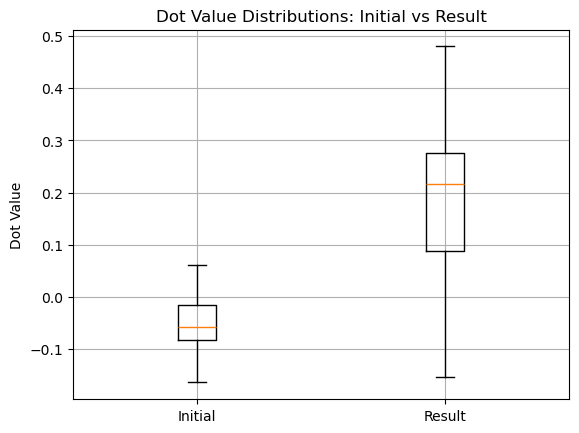

In [46]:
# Create the boxplot
plt.boxplot([df[df["SCD"] > 10]['dot_init'], df[df["SCD"] > 10]['dot_result']], labels=['Initial', 'Result'])
plt.ylabel('Dot Value')
plt.title('Dot Value Distributions: Initial vs Result')
plt.grid(True)
plt.show()

In [ ]:
batch_size = 4
flank_size = 15
ctcf_ohe_seqs = []  # list to collect OHE motif+flank arrays
ctcf_ohe_scores = [] # FIMO

model.eval()
with torch.no_grad():
    for edited_batch in edited_loader:
        
        edited_batch = edited_batch.to(device)
        edited_slice = edited_batch[:, :, edit_start:edit_end]  # shape: [B, 4, L]
        
        hits = fimo.fimo(
            motifs=motifs_dict,
            sequences=edited_slice,
            threshold=1e-4,
            reverse_complement=True
        )[0]
        
        for seq_idx in range(batch_size):
            seq_hits = hits[hits["sequence_name"] == seq_idx]
            
            if not seq_hits.empty:
                for _, row in seq_hits.iterrows():
                    start = int(row["start"]) - flank_size
                    end = int(row["end"]) + flank_size
                    strand = row["strand"]
                    
                    # Make sure bounds are within slice
                    if start < 0 or end > edited_slice.shape[-1]:
                        continue
                    
                    subseq = edited_slice[seq_idx, :, start:end]  # shape: [4, motif_len+30]
                    
                    if strand == '-':
                        # Reverse sequence
                        subseq = torch.flip(subseq, dims=[-1])  # reverse along the sequence axis

                        # Complement the one-hot rows: A<->T, C<->G
                        complement_map = torch.tensor([3, 2, 1, 0], device=subseq.device)  # old row i becomes new row complement_map[i]
                        subseq = subseq[complement_map, :]
    
                    ctcf_ohe_seqs.append(subseq.cpu().numpy())  # store as numpy array
                    ctcf_ohe_scores.append(row["score"])

In [ ]:
top_indices = np.argsort(ctcf_ohe_scores)[-20:][::-1]  # descending order

In [ ]:
# Extract the top sequences
top_ctcf_ohe = [ctcf_ohe_seqs[i] for i in top_indices]
top_scores = [ctcf_ohe_scores[i] for i in top_indices]

In [ ]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list

In [ ]:
# Assume top_ctcf_ohe is a list of 20 np.arrays with shape (4, 49)
# Stack them into a single array of shape (20, 4, 49)
seq_array = np.stack(top_ctcf_ohe)  # shape: [20, 4, 49]

# Convert from one-hot to integer-encoded sequences (A=0, C=1, G=2, T=3)
int_encoded = np.argmax(seq_array, axis=1)  # shape: [20, 49]

# Compute pairwise Hamming distances
distance_matrix = squareform(pdist(int_encoded, metric='hamming'))

# Use hierarchical clustering to order sequences
order = leaves_list(linkage(distance_matrix))

# Reorder the sequences
ordered_seqs = int_encoded[order]  # shape: [20, 49]

In [ ]:
# Map base integers to RGB colors
color_map = {
    0: [0.0, 1.0, 0.0],   # A - green
    1: [0.0, 0.0, 1.0],   # C - blue
    2: [1.0, 1.0, 0.0],   # G - yellow
    3: [1.0, 0.0, 0.0],   # T - red
}
rgb_array = np.array([[color_map[base] for base in row] for row in ordered_seqs])  # shape: [20, 49, 3]

In [ ]:
# Plotting
plt.figure(figsize=(12, 6))
plt.imshow(rgb_array, aspect='auto')
plt.title('Ordered CTCF Motifs (by Hamming Distance)')
plt.xlabel('Position')
plt.ylabel('Sequence Index')
plt.xticks(ticks=np.linspace(0, 48, 7), labels=[f'{int(x)}' for x in np.linspace(1, 49, 7)])
plt.yticks(ticks=np.arange(20), labels=[str(i + 1) for i in range(20)])
plt.tight_layout()
plt.show()

### SCD

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df["SCD"], bins=30, color='steelblue', edgecolor='black')
plt.xlabel("SCD")
plt.ylabel("Count")
plt.title("Distribution of SCD values")
plt.tight_layout()
plt.show()

In [ ]:
# Make sure scd_values is a list or Series of same length as pivoted
assert len(scd_values) == len(df), "Length mismatch!"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

state_labels = ["active", "neutral", "repressive"]

for i, label in enumerate(state_labels):
    axes[i].scatter(scd_values, df[f"{label}_fraction"], alpha=0.7)
    axes[i].set_title(f"{label.capitalize()} Fraction vs SCD")
    axes[i].set_xlabel("SCD Value")
    if i == 0:
        axes[i].set_ylabel("Fraction")

plt.tight_layout()
plt.show()

### URQ mean

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(urq_mean_values, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("URQ mean")
plt.ylabel("Count")
plt.title("Distribution of URQ mean values")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(target_urq_mean_values, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("Target URQ mean")
plt.ylabel("Count")
plt.title("Distribution of Target URQ mean values")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr

In [ ]:
# Compute Pearson R
r_val, p_val = pearsonr(urq_mean_values, target_urq_mean_values)

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(urq_mean_values, target_urq_mean_values, alpha=0.6, edgecolors='k')

plt.xlabel("Edited URQ Mean")
plt.ylabel("Target URQ Mean")
plt.title("URQ Mean: Edited vs. Target")

# Annotate with Pearson R
plt.text(0.05, 0.95, f"Pearson R = {r_val:.3f}", transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Make sure scd_values is a list or Series of same length as pivoted
assert len(urq_mean_values) == len(df), "Length mismatch!"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

state_labels = ["active", "neutral", "repressive"]

for i, label in enumerate(state_labels):
    axes[i].scatter(urq_mean_values, df[f"{label}_fraction"], alpha=0.7)
    axes[i].set_title(f"{label.capitalize()} Fraction vs URQ mean")
    axes[i].set_xlabel("URQ mean")
    if i == 0:
        axes[i].set_ylabel("Fraction")

plt.tight_layout()
plt.show()

### edit count

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(edit_counts, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("Number of edits / 2048bp-long bin")
plt.ylabel("Count")
plt.title("Distribution of edits number")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df["last_accepted_step_query"], bins=30, color='steelblue', edgecolor='black')
plt.xlabel("Last step with accepted edits")
plt.ylabel("Count")
plt.title("Distribution of last step with accepted edits")
plt.tight_layout()
plt.show()

### GC content

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(edit_counts, seq_GC_content, alpha=0.6, edgecolors='k')

plt.xlabel("number of edits")
plt.ylabel("Seq GC content")
plt.title("number of edits vs. Seq GC content")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(df["last_accepted_step_query"], seq_GC_content, alpha=0.6, edgecolors='k')

plt.xlabel("last step with accepted edit")
plt.ylabel("Seq GC content")
plt.title("last step with accepted edit vs. Seq GC content")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(urq_mean_values, seq_GC_content, alpha=0.6, edgecolors='k')

plt.xlabel("URQ mean")
plt.ylabel("Seq GC content")
plt.title("URQ mean vs. Seq GC content")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# df.to_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold{FOLD}_{TARGET_C}_all_data.tsv", sep="\t", index=False)

In [34]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [41]:
df[df["SCD"] < 10]["SCD"]

2     5.663370
6     7.663284
11    4.517582
21    6.318433
41    4.200000
42    6.359897
Name: SCD, dtype: float32

0


<Figure size 500x500 with 0 Axes>

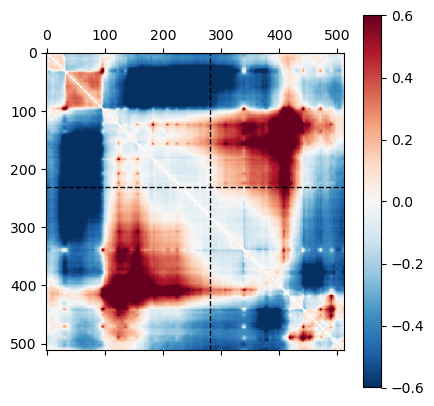

1


<Figure size 500x500 with 0 Axes>

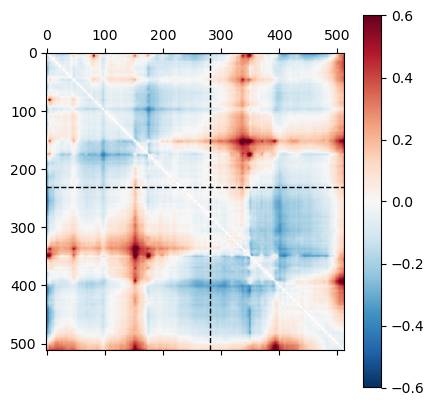

2


<Figure size 500x500 with 0 Axes>

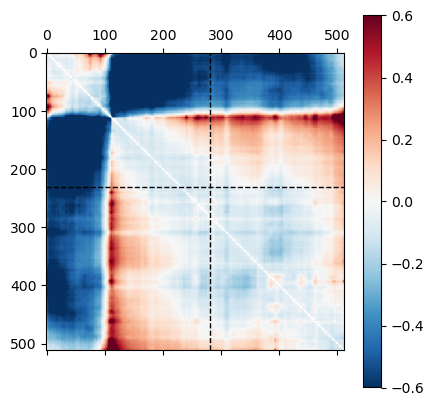

3


<Figure size 500x500 with 0 Axes>

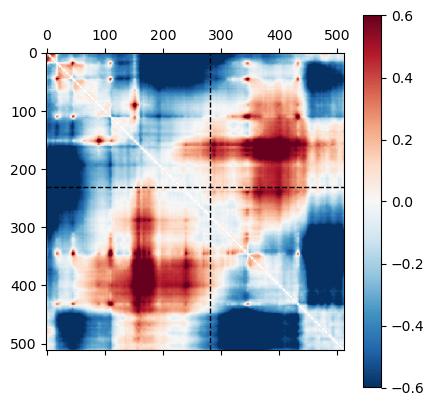

In [37]:
for i in range(4):
    print(i)
    matrix = from_upper_triu(orig_preds_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    
    # Get current Axes and add lines
    ax = plt.gca()
    ax.axhline(y=256 - 25, color='black', linestyle='--', linewidth=1)
    ax.axvline(x=256 + 25, color='black', linestyle='--', linewidth=1)
    
    plt.colorbar()
    plt.show()

0


<Figure size 500x500 with 0 Axes>

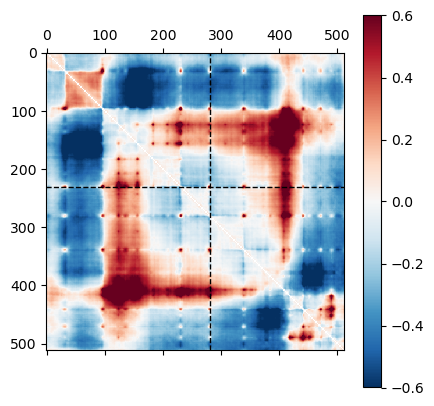

1


<Figure size 500x500 with 0 Axes>

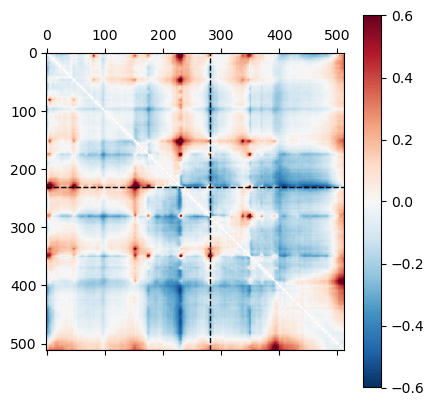

2


<Figure size 500x500 with 0 Axes>

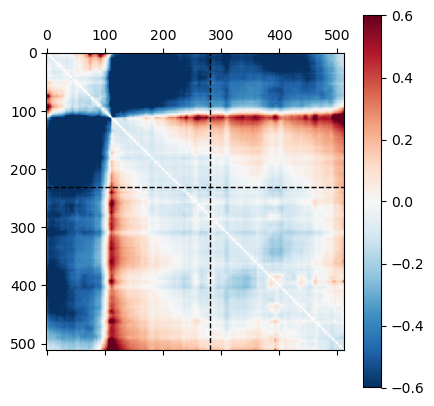

3


<Figure size 500x500 with 0 Axes>

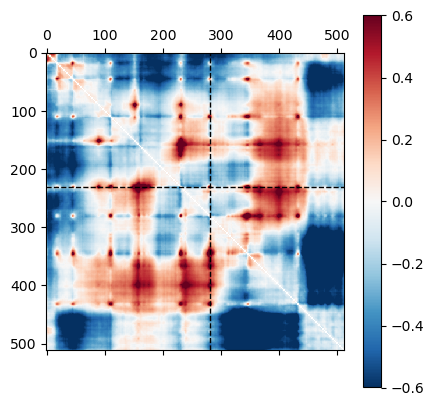

In [38]:
for i in range(4):
    print(i)
    matrix = from_upper_triu(edited_preds_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    
    # Get current Axes and add lines
    ax = plt.gca()
    ax.axhline(y=256 - 25, color='black', linestyle='--', linewidth=1)
    ax.axvline(x=256 + 25, color='black', linestyle='--', linewidth=1)
    
    plt.colorbar()
    plt.show()

0


<Figure size 500x500 with 0 Axes>

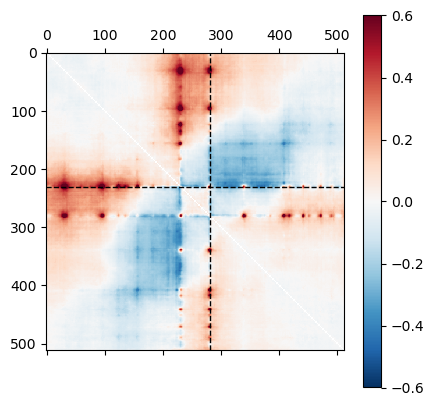

1


<Figure size 500x500 with 0 Axes>

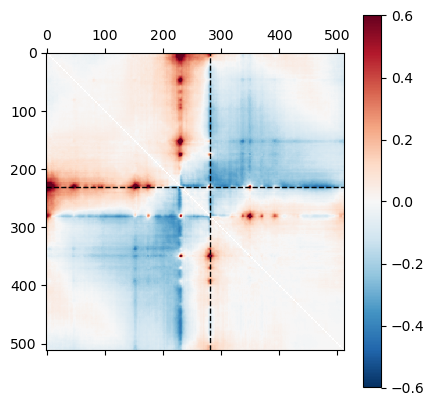

2


<Figure size 500x500 with 0 Axes>

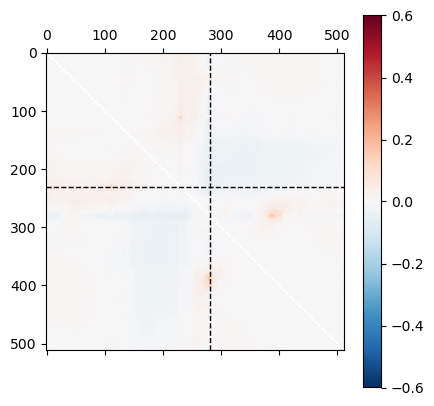

3


<Figure size 500x500 with 0 Axes>

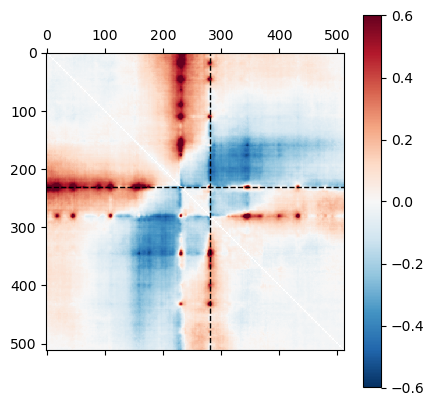

In [39]:
for i in range(4):
    print(i)
    matrix = from_upper_triu(edited_preds_all[i,:] - orig_preds_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    
    # Get current Axes and add lines
    ax = plt.gca()
    ax.axhline(y=256 - 25, color='black', linestyle='--', linewidth=1)
    ax.axvline(x=256 + 25, color='black', linestyle='--', linewidth=1)
    
    plt.colorbar()
    plt.show()

0


<Figure size 500x500 with 0 Axes>

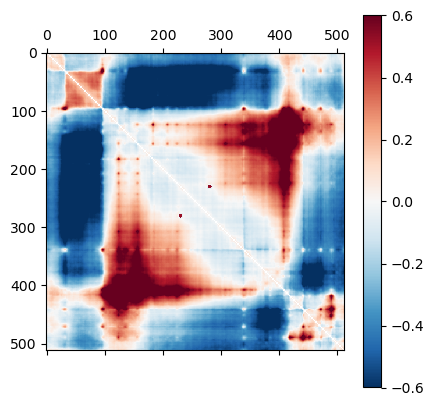

1


<Figure size 500x500 with 0 Axes>

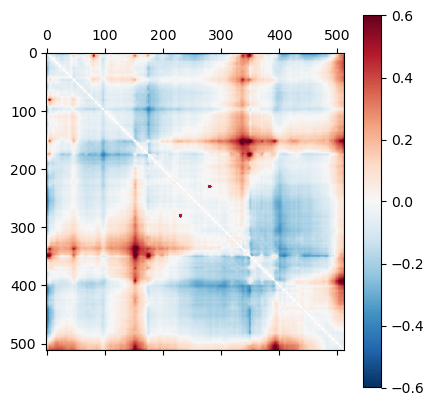

2


<Figure size 500x500 with 0 Axes>

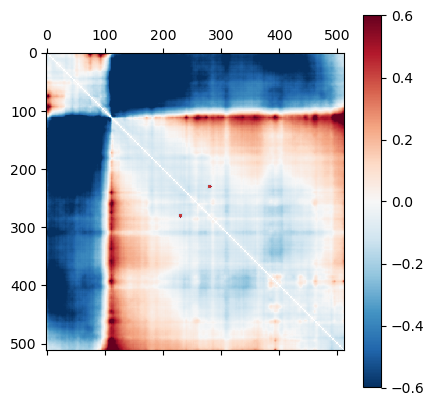

3


<Figure size 500x500 with 0 Axes>

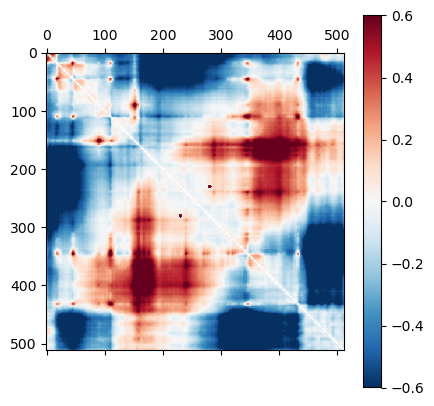

In [40]:
for i in range(4):
    print(i)
    matrix = from_upper_triu(targets_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    
    plt.colorbar()
    plt.show()

In [ ]:
df